# Prior predictive checks for EOS models

This notebook draws $N_{\rm EOS}$ samples from the prior distributions of the EOS parametrizations available for Bayesian inference in JESTER, solves the TOV equations for each sample, and plots the resulting ensemble of neutron star properties. This is a useful sanity check before running full Bayesian inference: it shows the range of neutron star properties that the prior allows and helps identify parametrizations that are too broad or too narrow.

The three parametrizations covered are:

- **MetaModel + CSE** — Metamodel at lower densities, stitched to a piecewise speed-of-sound extension (CSE) at higher densities.
- **MetaModel + peakCSE** — same as before, but the high-density extension uses a Gaussian peak plus a logistic growth term to model phase transitions.
- **Spectral (reparametrized)** — spectral decomposition of the adiabatic index (Lindblom 2010), reparametrized so the parameters are naturally sampled from a unit Gaussian distribution.

For all models we use the GR TOV solver and show four diagnostic plots per parametrization: pressure vs. baryon number density, speed of sound squared vs. density, mass–radius curves, and mass–tidal deformability curves.

## Words of caution

This notebook is designed to help users show how to (i) use the jester infrastructure to draw parameter samples from the priors, (ii) solve the TOV equations for each sample, and (iii) plot the resulting neutron star properties. It is not meant to be a comprehensive exploration of the prior space of each parametrization. Moreover, be aware that some samples drawn from some parametrizations might be unphysical (e.g., violate causality or stability) and therefore lead to nonsensical results which have to be caught during inference. In ``jester``, this can be done using the ``ConstraintsLikelihood`` class, which penalizes unphysical samples in order to discourage the samplers from exploring such parameter spaces.

However, in this notebook we do not apply any such constraints, and simply show the raw prior samples. Should you wish to learn more about how this is done, check out the inference guide to learn how to run Bayesian inferences, and run a 'prior-only' inference to see the 'effective priors' that result from applying the constraints.

In [52]:
import jax
import numpy as np
import matplotlib.pyplot as plt

import jesterTOV.utils as utils
from jesterTOV.tov.gr import GRTOVSolver
from jesterTOV.tov.data_classes import EOSData, FamilyData
from jesterTOV.inference.base.prior import Prior, UniformPrior, MultivariateGaussianPrior, CombinePrior

fs = 16
params = {"axes.grid": False,
        "text.usetex" : True,
        "font.family" : "serif",
        "font.serif" : ["Computer Modern Serif"],
        "ytick.color" : "black",
        "xtick.color" : "black",
        "axes.labelcolor" : "black",
        "axes.edgecolor" : "black",
        "xtick.labelsize": fs,
        "ytick.labelsize": fs,
        "axes.labelsize": fs,
        "legend.fontsize": fs,
        "legend.title_fontsize": fs,
        "figure.titlesize": fs}

plt.rcParams.update(params)

In [53]:
# Reproducibility and global settings
key = jax.random.PRNGKey(42)

N_EOS = 200          # number of prior samples per parametrization
nsat = 0.16          # nuclear saturation density [fm^-3]
M_MIN = 0.9          # minimum mass to include in M-R / M-Lambda plots [M_sun]

# Shared TOV solver
tov_solver = GRTOVSolver()

In [54]:
def plot_prior_predictive(
    eos_list: list[EOSData],
    family_list: list[FamilyData],
    nmax_nsat: float
) -> None:
    """
    Plot four diagnostic panels for an ensemble of EOS/TOV solutions.
    Plot (i) pressure, (ii) sound speed, (iii) mass-radius, and (iv) mass-tidal deformability panels
    """

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ax_p, ax_cs2, ax_mr, ax_ml = axes.flat

    for eos_data, fam in zip(eos_list, family_list):
        ns_nsat = np.array(eos_data.ns) / utils.fm_inv3_to_geometric / nsat
        ps_phys = np.array(eos_data.ps) / utils.MeV_fm_inv3_to_geometric
        cs2 = np.array(eos_data.cs2)

        masses = np.array(fam.masses)
        radii = np.array(fam.radii)
        lambdas = np.array(fam.lambdas)

        mask = masses > M_MIN
        color = "blue"
        
        plot_kwargs = {"color": color, "alpha": 0.7, "lw": 0.8}

        ax_p.plot(ns_nsat, ps_phys, **plot_kwargs)
        ax_cs2.plot(ns_nsat, cs2, **plot_kwargs)
        ax_mr.plot(radii[mask], masses[mask], **plot_kwargs)
        ax_ml.plot(masses[mask], lambdas[mask], **plot_kwargs)

    ax_p.set_xlabel(r"Density $[n_{\rm sat}]$")
    ax_p.set_ylabel(r"Pressure $[{\rm MeV\,fm^{-3}}]$")
    ax_p.set_yscale("log")
    ax_p.set_ylim(bottom=1e-2)
    ax_p.set_xlim(left=0.5, right=nmax_nsat) # nsat

    ax_cs2.set_xlabel(r"Density $[n_{\rm sat}]$")
    ax_cs2.set_ylabel(r"$c_s^2 / c^2$")
    ax_cs2.legend(fontsize=8)
    ax_cs2.set_xlim(left=0.5, right=nmax_nsat) # nsat
    
    ax_mr.set_xlabel(r"Radius $[{\rm km}]$")
    ax_mr.set_ylabel(r"Mass $[M_\odot]$")
    ax_mr.set_ylim(bottom=M_MIN)

    ax_ml.set_xlabel(r"Mass $[M_\odot]$")
    ax_ml.set_ylabel(r"$\Lambda$")
    ax_ml.set_yscale("log")
    ax_ml.set_xlim(left=M_MIN)

    plt.tight_layout()
    plt.show()
    plt.close()

In [55]:
# Individual NEP priors shared across all metamodel variants
nep_priors = [
    UniformPrior(-16.1,   -15.9, parameter_names=["E_sat"]),
    UniformPrior( 150.0,   300.0, parameter_names=["K_sat"]),
    UniformPrior(-500.0,  1100.0, parameter_names=["Q_sat"]),
    UniformPrior(-2500.0, 1500.0, parameter_names=["Z_sat"]),
    UniformPrior(  28.0,    45.0, parameter_names=["E_sym"]),
    UniformPrior(  10.0,   200.0, parameter_names=["L_sym"]),
    UniformPrior(-400.0,   200.0, parameter_names=["K_sym"]),
    UniformPrior(-1000.0, 1500.0, parameter_names=["Q_sym"]),
    UniformPrior(-2000.0, 1500.0, parameter_names=["Z_sym"]),
]

---

## MetaModel + CSE

The metamodel with constant speed-of-sound extension (CSE) keeps the NEP base and introduces a break density $n_{\rm break}$ at which the parametrization switches to a piecewise-constant speed of sound on a set of $N_{b}$ grid points. Each grid point $i$ has a fractional density position $n_{\rm CSE,i}^{\rm u} \in [0,1]$ (mapped linearly to $[n_{\rm break}, n_{\rm max}]$) and a speed of sound squared $c_{s,i}^2 \in [0,1]$. Here we use $N_{b} = 4$ grid points.

Successful EOS constructions: 200 / 200


/var/folders/xj/6sk96vdn15385fpjn9nd1rcw0000gp/T/ipykernel_18895/1626323630.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_cs2.legend(fontsize=8)


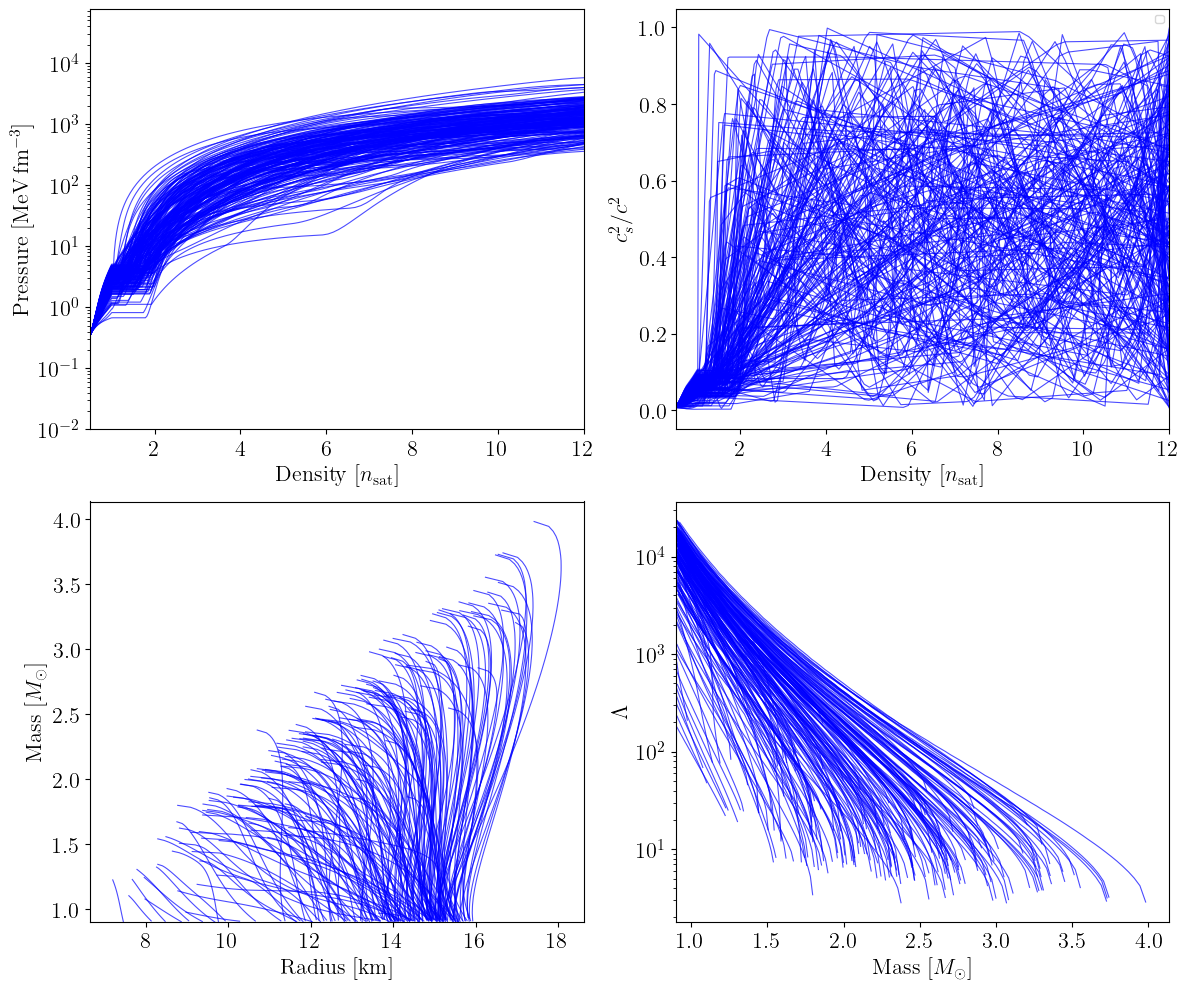

In [56]:
from jesterTOV.eos.metamodel.metamodel_CSE import MetaModel_with_CSE_EOS_model

key, subkey = jax.random.split(key)

### Define EOS model
NB_CSE = 4
nmax_nsat = 12.0
eos_cse = MetaModel_with_CSE_EOS_model(nmax_nsat=nmax_nsat, nb_CSE=NB_CSE, max_nbreak_nsat=1.0)

### Define MM+CSE priors
CSE_prior = [UniformPrior(0.16, 0.32, parameter_names=["nbreak"])]
for i in range(NB_CSE):
    CSE_prior.append(UniformPrior(0.0, 1.0, parameter_names=[f"n_CSE_{i}_u"]))

# NOTE: the final density point is fixed at nmax_nsat, so one more cs2 parameter is needed than n_CSE parameters
for i in range(NB_CSE + 1):
    CSE_prior.append(UniformPrior(0.0, 1.0, parameter_names=[f"cs2_CSE_{i}"]))

full_prior_list: list[Prior] = nep_priors + CSE_prior # type: ignore
cse_prior = CombinePrior(full_prior_list)

## Sample and solve TOV
samples = cse_prior.sample(subkey, N_EOS)

eos_list_cse: list[EOSData] = []
family_list_cse: list[FamilyData] = []

for i in range(N_EOS):
    params = {k: float(v[i]) for k, v in samples.items()}
    try:
        eos_data = eos_cse.construct_eos(params)
        fam = tov_solver.construct_family(eos_data, ndat=100, min_nsat=0.75, tov_params={})
        eos_list_cse.append(eos_data)
        family_list_cse.append(fam)
    except Exception:
        pass

print(f"Successful EOS constructions: {len(eos_list_cse)} / {N_EOS}")
plot_prior_predictive(eos_list_cse, family_list_cse, nmax_nsat=nmax_nsat)

---

## MetaModel + peakCSE

The peakCSE extension replaces the piecewise-constant CSE with a physically motivated functional form that combines a Gaussian peak (modelling a possible phase transition) with a logistic sigmoid (ensuring a smooth approach to the conformal limit $c_s^2 = 1/3$ at high densities). The free parameters are the peak amplitude $c_{s,{\rm peak}}^2$, center $n_{\rm peak}$, width $\sigma_{\rm peak}$, logistic growth rate $l_{\rm sig}$, and logistic midpoint $n_{\rm sig}$.

Successful EOS constructions: 200 / 200


/var/folders/xj/6sk96vdn15385fpjn9nd1rcw0000gp/T/ipykernel_18895/1626323630.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_cs2.legend(fontsize=8)


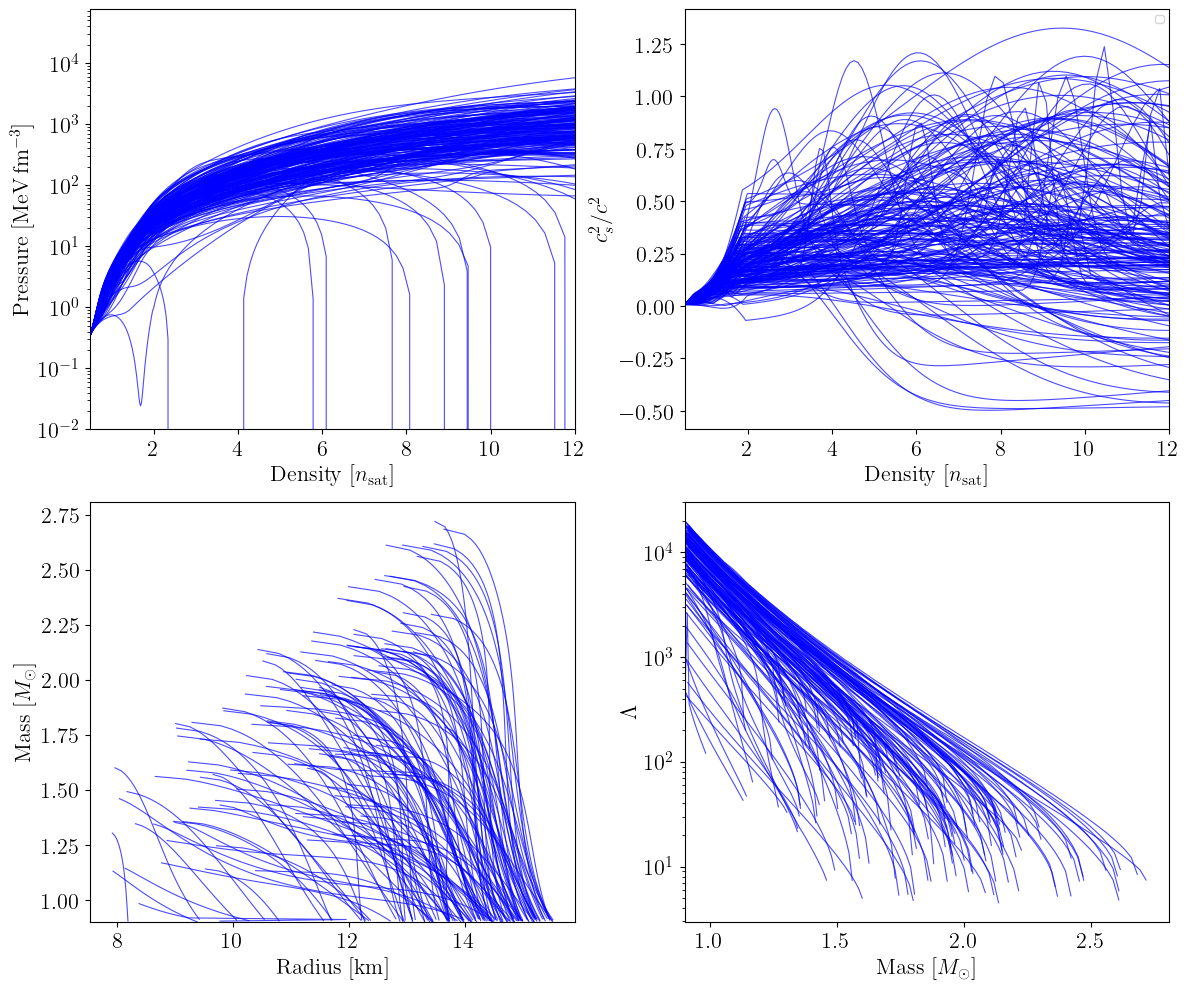

In [57]:
from jesterTOV.eos.metamodel.metamodel_peakCSE import MetaModel_with_peakCSE_EOS_model

key = jax.random.PRNGKey(43)
key, subkey = jax.random.split(key)

nmax_nsat = 12.0
eos_pcse = MetaModel_with_peakCSE_EOS_model(nmax_nsat=nmax_nsat, max_nbreak_nsat=0.32 / nsat)

pcse_priors = [
        UniformPrior(0.16,  0.32, parameter_names=["nbreak"]),
        UniformPrior(0.1,   1.0,  parameter_names=["gaussian_peak"]),
        UniformPrior(0.32,  1.92, parameter_names=["gaussian_mu"]),
        UniformPrior(0.016, 0.8,  parameter_names=["gaussian_sigma"]),
        UniformPrior(0.1,   1.0,  parameter_names=["logit_growth_rate"]),
        UniformPrior(0.32,  5.6,  parameter_names=["logit_midpoint"]),
    ]

full_prior_list = nep_priors + pcse_priors
pcse_prior = CombinePrior(full_prior_list) # type: ignore

samples = pcse_prior.sample(subkey, N_EOS)

eos_list_pcse: list[EOSData] = []
family_list_pcse: list[FamilyData] = []

for i in range(N_EOS):
    params = {k: float(v[i]) for k, v in samples.items()}
    try:
        eos_data = eos_pcse.construct_eos(params)
        fam = tov_solver.construct_family(eos_data, ndat=100, min_nsat=0.75, tov_params={})
        eos_list_pcse.append(eos_data)
        family_list_pcse.append(fam)
    except Exception:
        pass

print(f"Successful EOS constructions: {len(eos_list_pcse)} / {N_EOS}")
plot_prior_predictive(eos_list_pcse, family_list_pcse, nmax_nsat=nmax_nsat)

---

## Spectral (reparametrized)

The spectral parametrization (Lindblom 2010) expresses the adiabatic index as $\log \Gamma(x) = \gamma_0 + \gamma_1 x + \gamma_2 x^2 + \gamma_3 x^3$, where $x$ is a rescaled pressure. Rather than sampling the $\gamma_i$ directly from wide uniform ranges, we use the reparametrized form in which the spectral coefficients are mapped to tilde parameters $\tilde{\gamma}_i$ that follow a standard multivariate Gaussian prior centred on a representative EOS (the radio-timing posterior mean). This concentrates prior mass on physically reasonable solutions while still permitting broad exploration.

[INFO] jester: Initialized SpectralDecomposition_EOS_model with crust=SLy, n_points=500
Successful EOS constructions: 200 / 200


/var/folders/xj/6sk96vdn15385fpjn9nd1rcw0000gp/T/ipykernel_18895/1626323630.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_cs2.legend(fontsize=8)


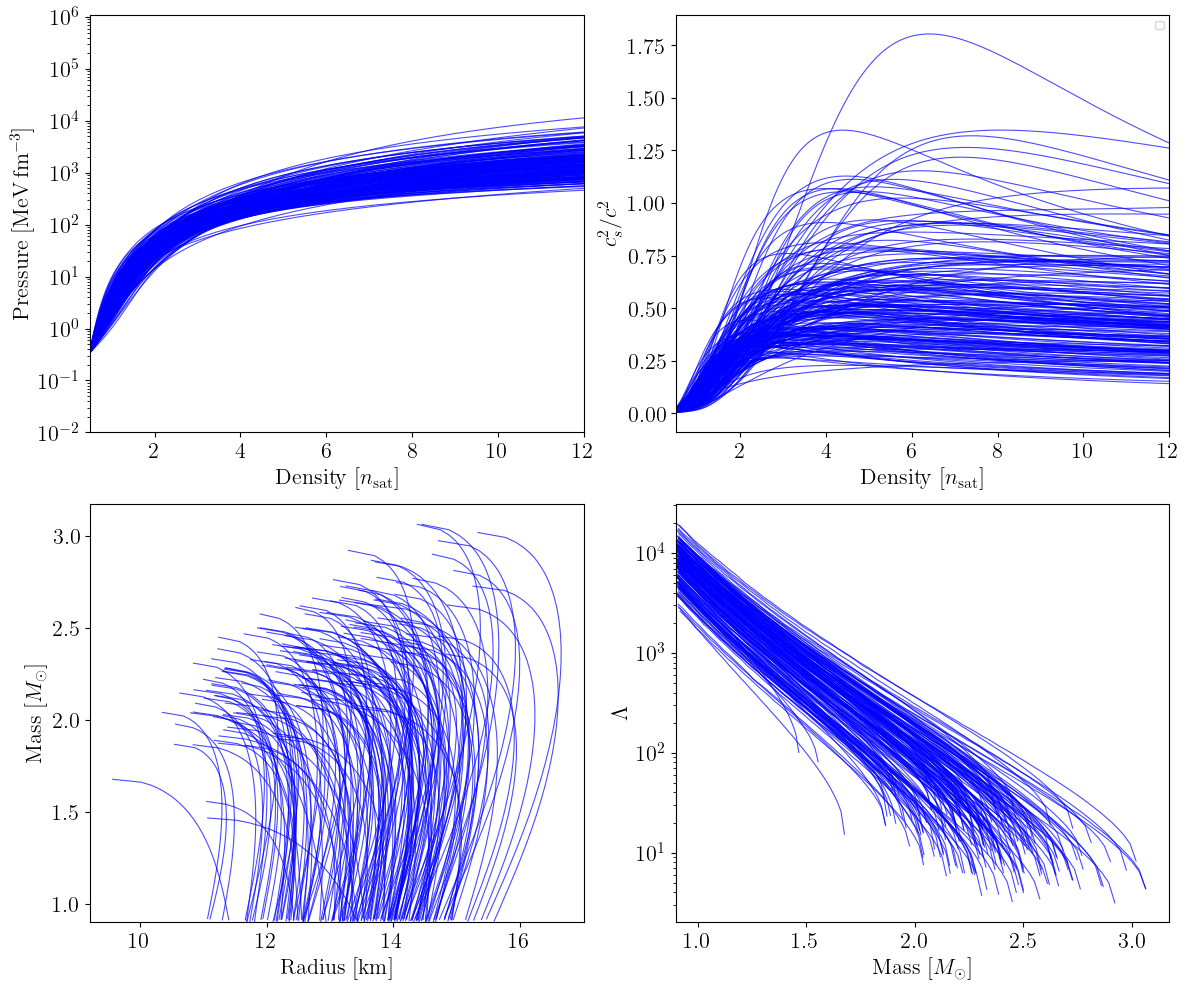

In [58]:
from jesterTOV.eos.spectral.spectral_decomposition import SpectralDecomposition_EOS_model

key, subkey = jax.random.split(key)

nmax_nsat = 12.0
eos_spectral = SpectralDecomposition_EOS_model(reparametrized=True)

# Standard multivariate Gaussian (mean=0, cov=I) for the four tilde parameters
spectral_prior = MultivariateGaussianPrior(
    parameter_names=["gamma_0_tilde", "gamma_1_tilde", "gamma_2_tilde", "gamma_3_tilde"]
)

samples = spectral_prior.sample(subkey, N_EOS)

eos_list_spec: list[EOSData] = []
family_list_spec: list[FamilyData] = []

for i in range(N_EOS):
    params = {k: float(v[i]) for k, v in samples.items()}
    try:
        eos_data = eos_spectral.construct_eos(params)
        fam = tov_solver.construct_family(eos_data, ndat=100, min_nsat=0.75, tov_params={})
        eos_list_spec.append(eos_data)
        family_list_spec.append(fam)
    except Exception:
        pass

print(f"Successful EOS constructions: {len(eos_list_spec)} / {N_EOS}")
plot_prior_predictive(eos_list_spec, family_list_spec, nmax_nsat=nmax_nsat)